In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

from scipy.stats import linregress
import DataProcessor

In [2]:
RUPTURE_POSITIONS = [115, 110, 105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]
STIFFNESSES = [750, 1500, 3000, 6000, 12000]

E_AVERAGE = []
E_STD = []

G_AVERAGE = []
G_STD = []

G80_AVERAGE = []
G80_STD = []

In [3]:
# for STIFFNESS in STIFFNESSES:
#     folder_path = f"./Stiffness/Y{STIFFNESS}"

#     spring_energies = []

#     for RUPTURE_POSITION in RUPTURE_POSITIONS:
        
#         filename = f'strain-energy-{RUPTURE_POSITION}.npz'
#         file_path = os.path.join(folder_path, filename)
#         if not os.path.exists(file_path):
#             print(f"[WARNING] File {filename} not found. Skipping.")
#             continue
#         data = np.load(file_path)
#         spring_energies.append(data.get('ELSE-Spring', np.nan))


#     spring_energies = np.array(spring_energies)
#     G_spring = -np.gradient(spring_energies, RUPTURE_POSITIONS)

#     G_AVERAGE.append(np.mean(G_spring))
#     G_STD.append(np.std(G_spring))
    
#     G80_AVERAGE.append(G_spring[7])

#     plot_individual = True
#     if plot_individual:

#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

#         ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-', label='Spring Energy')
#         ax1.set_ylabel('Strain Energy')
#         ax1.set_title(f'Spring Energy vs. Rupture Position, Displacement Control, {STIFFNESS:.1f}MPa')
#         ax1.grid(True)
#         ax1.legend()
#         ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', label='Spring Energy Gradient', color='tab:orange')
#         ax2.set_xlabel('Rupture Position (mm)')
#         ax2.set_ylabel('Energy Gradient')
#         ax2.set_title('Gradient of Spring Energy vs. Rupture Position')
#         ax2.grid(True)
#         ax2.legend()

#         plt.tight_layout()
#         # plt.savefig(f'./Stiffness/Plots/DC-Y{STIFFNESS}MPa.pdf', dpi=300)
#         # plt.show()
#         plt.close()


# STIFFNESSES = np.array(STIFFNESSES)
# G_AVERAGE = np.array(G_AVERAGE)
# G80_AVERAGE = np.array(G80_AVERAGE)
# G_STD     = np.array(G_STD)

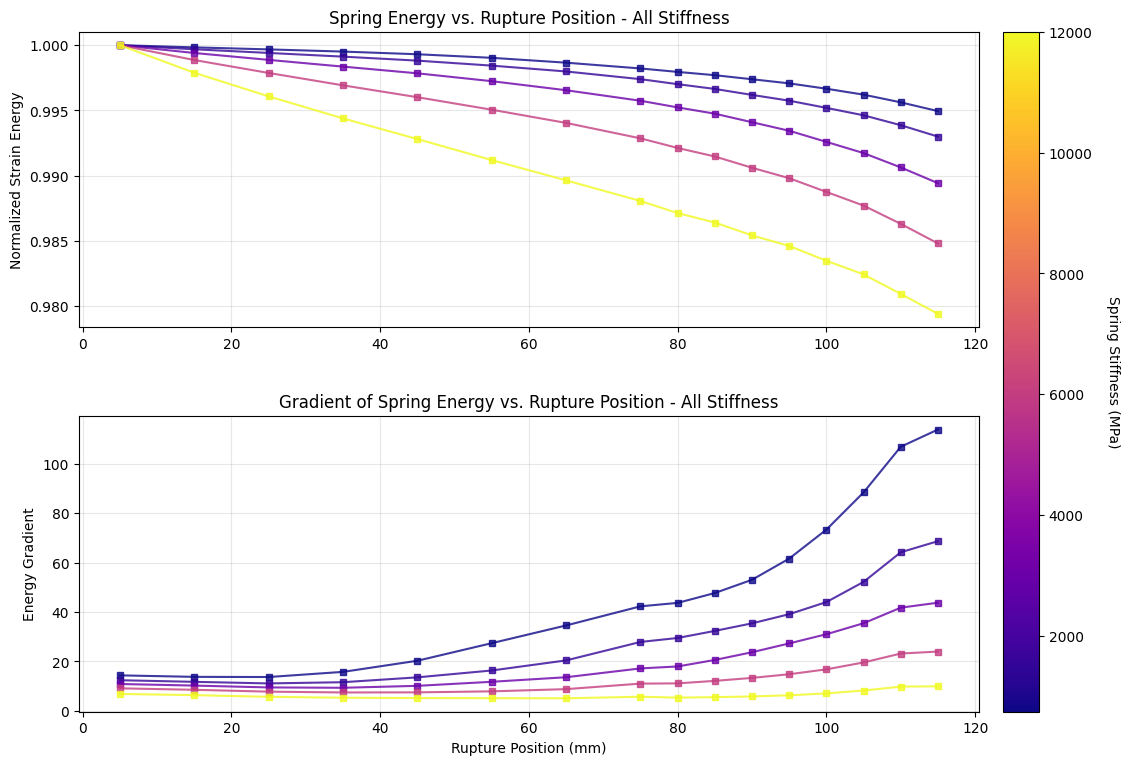

In [4]:
for STIFFNESS in STIFFNESSES:
    folder_path = f"./Stiffness/Y{STIFFNESS}"

    spring_energies = []

    for RUPTURE_POSITION in RUPTURE_POSITIONS:
        
        filename = f'strain-energy-{RUPTURE_POSITION}.npz'
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path):
            print(f"[WARNING] File {filename} not found. Skipping.")
            continue
        data = np.load(file_path)
        spring_energies.append(data.get('ELSE-Spring', np.nan))

    spring_energies = np.array(spring_energies)
    G_spring = -np.gradient(spring_energies, RUPTURE_POSITIONS)

    E_AVERAGE.append(np.mean(spring_energies))
    E_STD.append(np.std(spring_energies))

    G80_AVERAGE.append(G_spring[7])
    G_AVERAGE.append(np.mean(G_spring))
    G_STD.append(np.std(G_spring))

    if 'global_data' not in locals():
        global_data = []
    global_data.append({
        'mesh_size': STIFFNESS,
        'spring_energies': spring_energies,
        'G_spring': G_spring
    })

    plot_individual = True
    plot_Global = True
    if plot_individual:

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-', label='Spring Energy')
        ax1.set_ylabel('Strain Energy')
        ax1.set_title(f'Spring Energy vs. Rupture Position, Displacement Control, E = {STIFFNESS}MPa')
        ax1.grid(True)
        ax1.legend()
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', label='Spring Energy Gradient', color='tab:orange')
        ax2.set_xlabel('Rupture Position (mm)')
        ax2.set_ylabel('Energy Gradient')
        ax2.set_title('Gradient of Spring Energy vs. Rupture Position')
        ax2.grid(True)
        ax2.legend()

        plt.tight_layout()
        plt.savefig(f'./MeshDC/Plots/DC-{STIFFNESS}MPa.pdf', dpi=300)
        # plt.show()
        plt.close()


if plot_Global:
    fig = plt.figure(figsize=(12, 8))
    
    ax1 = plt.subplot(2, 1, 1)
    ax2 = plt.subplot(2, 1, 2)
    
    sorted_data = sorted(global_data, key=lambda x: x['mesh_size'])
    mesh_sizes = [data['mesh_size'] for data in sorted_data]
    
    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=min(mesh_sizes), vmax=max(mesh_sizes))
    
    for data in sorted_data:
        mesh_size = data['mesh_size']
        spring_energies = data['spring_energies']
        G_spring = data['G_spring']
        
        color = cmap(norm(mesh_size))
        
        ax1.plot(RUPTURE_POSITIONS, spring_energies / np.max(spring_energies), 's-',  color=color, alpha=0.8, markersize=4, linewidth=1.5)
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', color=color, alpha=0.8, markersize=4, linewidth=1.5)
    
    ax1.set_ylabel('Normalized Strain Energy')
    ax1.set_title('Spring Energy vs. Rupture Position - All Stiffness')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Rupture Position (mm)')
    ax2.set_ylabel('Energy Gradient')
    ax2.set_title('Gradient of Spring Energy vs. Rupture Position - All Stiffness')
    ax2.grid(True, alpha=0.3)
    ax2.sharex(ax1)
    
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.85, top=0.95, hspace=0.3)
    
    smap = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    smap.set_array([])
    cbar_ax = fig.add_axes([0.87, 0.1, 0.03, 0.85])
    cbar = fig.colorbar(smap, cax=cbar_ax)
    cbar.set_label('Spring Stiffness (MPa)', rotation=270, labelpad=20)
    
    plt.savefig('./Stiffness/Plots/DC-Global-All-Stiffness.pdf', dpi=300)
    plt.show()
    plt.close()


STIFFNESSES = np.array(STIFFNESSES)
G_AVERAGE = np.array(G_AVERAGE)
G80_AVERAGE = np.array(G80_AVERAGE)
G_STD     = np.array(G_STD)

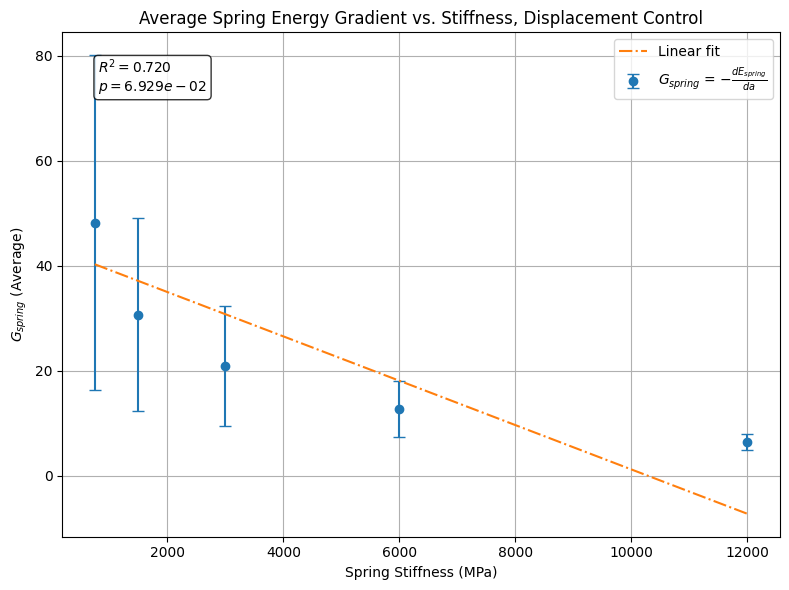

In [5]:
slope, intercept, r_value, p_value, std_err = linregress(STIFFNESSES, G_AVERAGE)
slope, intercept = DataProcessor.get_linear_regression(STIFFNESSES, G_AVERAGE, np.ones_like(STIFFNESSES), G_STD, slope, intercept)

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')

x_fit = np.linspace(min(STIFFNESSES), max(STIFFNESSES), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, '-.', label='Linear fit')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Spring Stiffness (MPa)')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy Gradient vs. Stiffness, Displacement Control')
plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G.pdf', dpi=300)
plt.show()
plt.close()

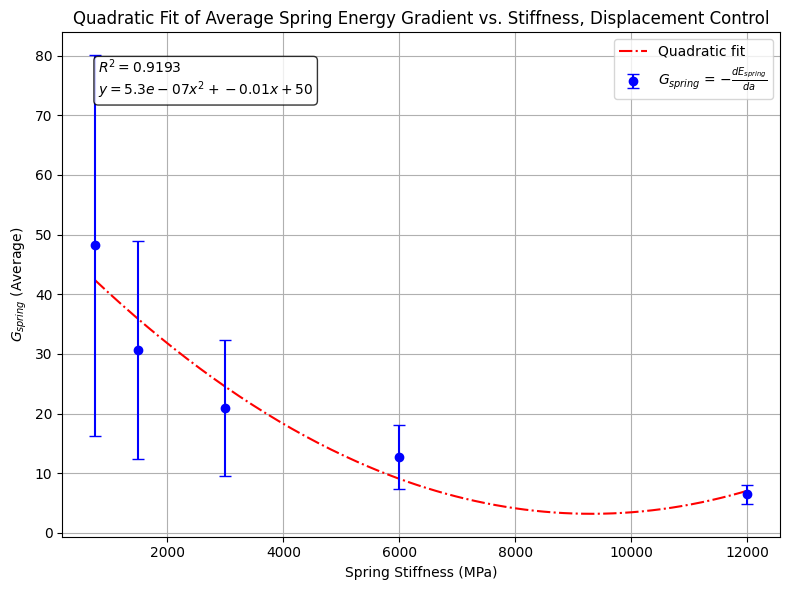

In [6]:

X = np.column_stack((STIFFNESSES**2, STIFFNESSES))
X = sm.add_constant(X)

model = sm.OLS(G_AVERAGE, X)
results = model.fit()
a, b, c = results.params[1], results.params[2], results.params[0]
r_squared = results.rsquared

x_fit = np.linspace(min(STIFFNESSES), max(STIFFNESSES), 200)
y_fit = a * x_fit**2 + b * x_fit + c

plt.figure(figsize=(8, 6))
plt.plot(x_fit, y_fit, 'r-.', label='Quadratic fit')
plt.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, color='blue', fmt='o', capsize=4, label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
plt.text(0.05, 0.95, f'$R^2 = {r_squared:.4f}$\n$y = {a:.2g}x^2 + {b:.2g}x + {c:.2g}$', transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Spring Stiffness (MPa)')
plt.ylabel(r'$G_{spring}$ (Average)')
plt.title('Quadratic Fit of Average Spring Energy Gradient vs. Stiffness, Displacement Control')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G-Quadratic.pdf', dpi=300)
plt.show()

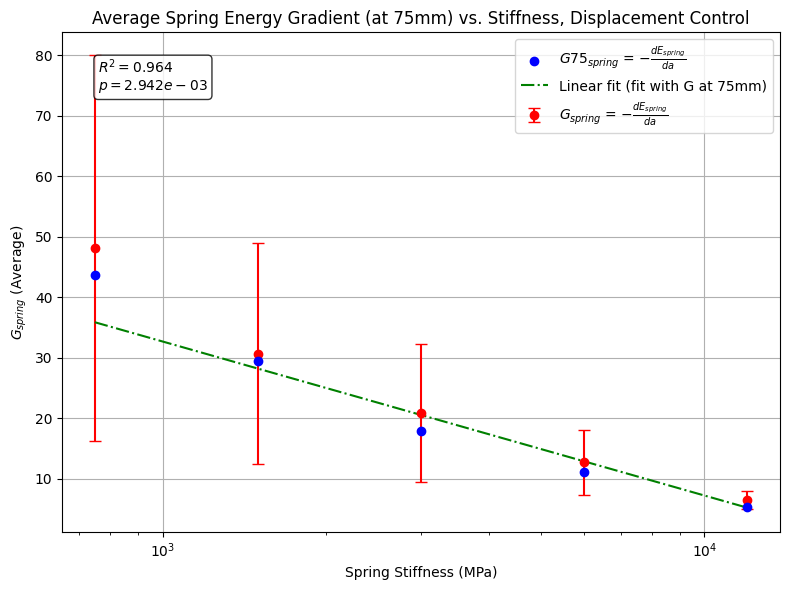

In [7]:
slope, intercept, r_value, p_value, std_err = linregress(np.log10(STIFFNESSES), G80_AVERAGE)
slope, intercept = DataProcessor.get_linear_regression(np.log10(STIFFNESSES), G80_AVERAGE, np.ones_like(STIFFNESSES), G_STD, slope, intercept)

fig, ax = plt.subplots(figsize=(8, 6))

# ax.errorbar(STIFFNESSES, G80_AVERAGE, yerr=G_STD, fmt='o', capsize=4, label=r'$G75_{spring}$ = $\frac{dE_{spring}}{da}$')
ax.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')

ax.scatter(STIFFNESSES, G80_AVERAGE, color='blue', label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder = 3)

x_fit = np.linspace(min(np.log10(STIFFNESSES)), max(np.log10(STIFFNESSES)), 100)
y_fit = slope * x_fit + intercept
ax.plot(10**x_fit, y_fit, '-.', color = "green", label='Linear fit (fit with G at 75mm)')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Spring Stiffness (MPa)')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy Gradient (at 75mm) vs. Stiffness, Displacement Control')
plt.xscale("log")
plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G75.pdf', dpi=300)
plt.show()
plt.close()